## Block 1: Imports, Data Loading & Colormap Setup

In [1]:
import os
import sys
import time
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from matplotlib.patches import Ellipse
from matplotlib.colors import LinearSegmentedColormap
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import norm
import optuna
from pykrige.ok import OrdinaryKriging

optuna.logging.set_verbosity(optuna.logging.WARNING)
sys.path.append(os.path.abspath('..'))
from igmn import IGMN

# 1. Define custom Parula colormap
parula_colors = [(0.208, 0.166, 0.529), (0.059, 0.358, 0.861), (0.012, 0.572, 0.829),
                 (0.128, 0.695, 0.552), (0.488, 0.771, 0.344), (0.852, 0.803, 0.231), (0.976, 0.983, 0.054)]
parula_map = LinearSegmentedColormap.from_list('parula', parula_colors)
parula_map.set_bad('white')

# 2. Load reservoir data
data = sio.loadmat('../data/data_CAGEO.mat', squeeze_me=True, struct_as_record=False)

Phi_ref = np.clip(data['Phi'], 0.01, None)
Sw13_ref = np.clip(data['Sw13'], 0.01, None)
Sw24_ref = np.clip(data['Sw24'], 0.01, None)

Ip13_ref, VPVS13_ref = data['Ip13'], data['VPVS13']
Ip24_ref, VPVS24_ref = data['Ip24'], data['VPVS24']

# 3. Extract well coordinates (float64 required for Kriging later)
wells_i = np.array([w.i - 1 for w in data['WELLS']], dtype=np.float64)
wells_j = np.array([w.j - 1 for w in data['WELLS']], dtype=np.float64)

def plot_wells_only(ax):
    """Helper function to plot well markers."""
    ax.scatter(wells_j, wells_i, marker='+', color='k', s=40, linewidths=1.2)

# 4. Extract valid reservoir cells for global scaling
valid_mask = ~np.isnan(Ip13_ref.flatten())
reservoir_data = np.column_stack((
    Ip13_ref.flatten()[valid_mask], VPVS13_ref.flatten()[valid_mask],
    Ip24_ref.flatten()[valid_mask], VPVS24_ref.flatten()[valid_mask],
    Phi_ref.flatten()[valid_mask], Sw13_ref.flatten()[valid_mask], Sw24_ref.flatten()[valid_mask]
))
print(f"Data successfully loaded. Reservoir cells: {len(reservoir_data)}")

c:\study\Geostat\igmn_project_python\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\study\Geostat\igmn_project_python\.venv\Lib\site-packages\scipy\io\matlab\_mio.py:236: MatReadWarning: Duplicate variable name "None" in stream - replacing previous with new
Considerscipy.io.matlab.varmats_from_mat to split file into single variable files
  matfile_dict = MR.get_variables(variable_names)


Data successfully loaded. Reservoir cells: 37208


## Block 2: Rock Physics, Monte Carlo Generation & Figure 14

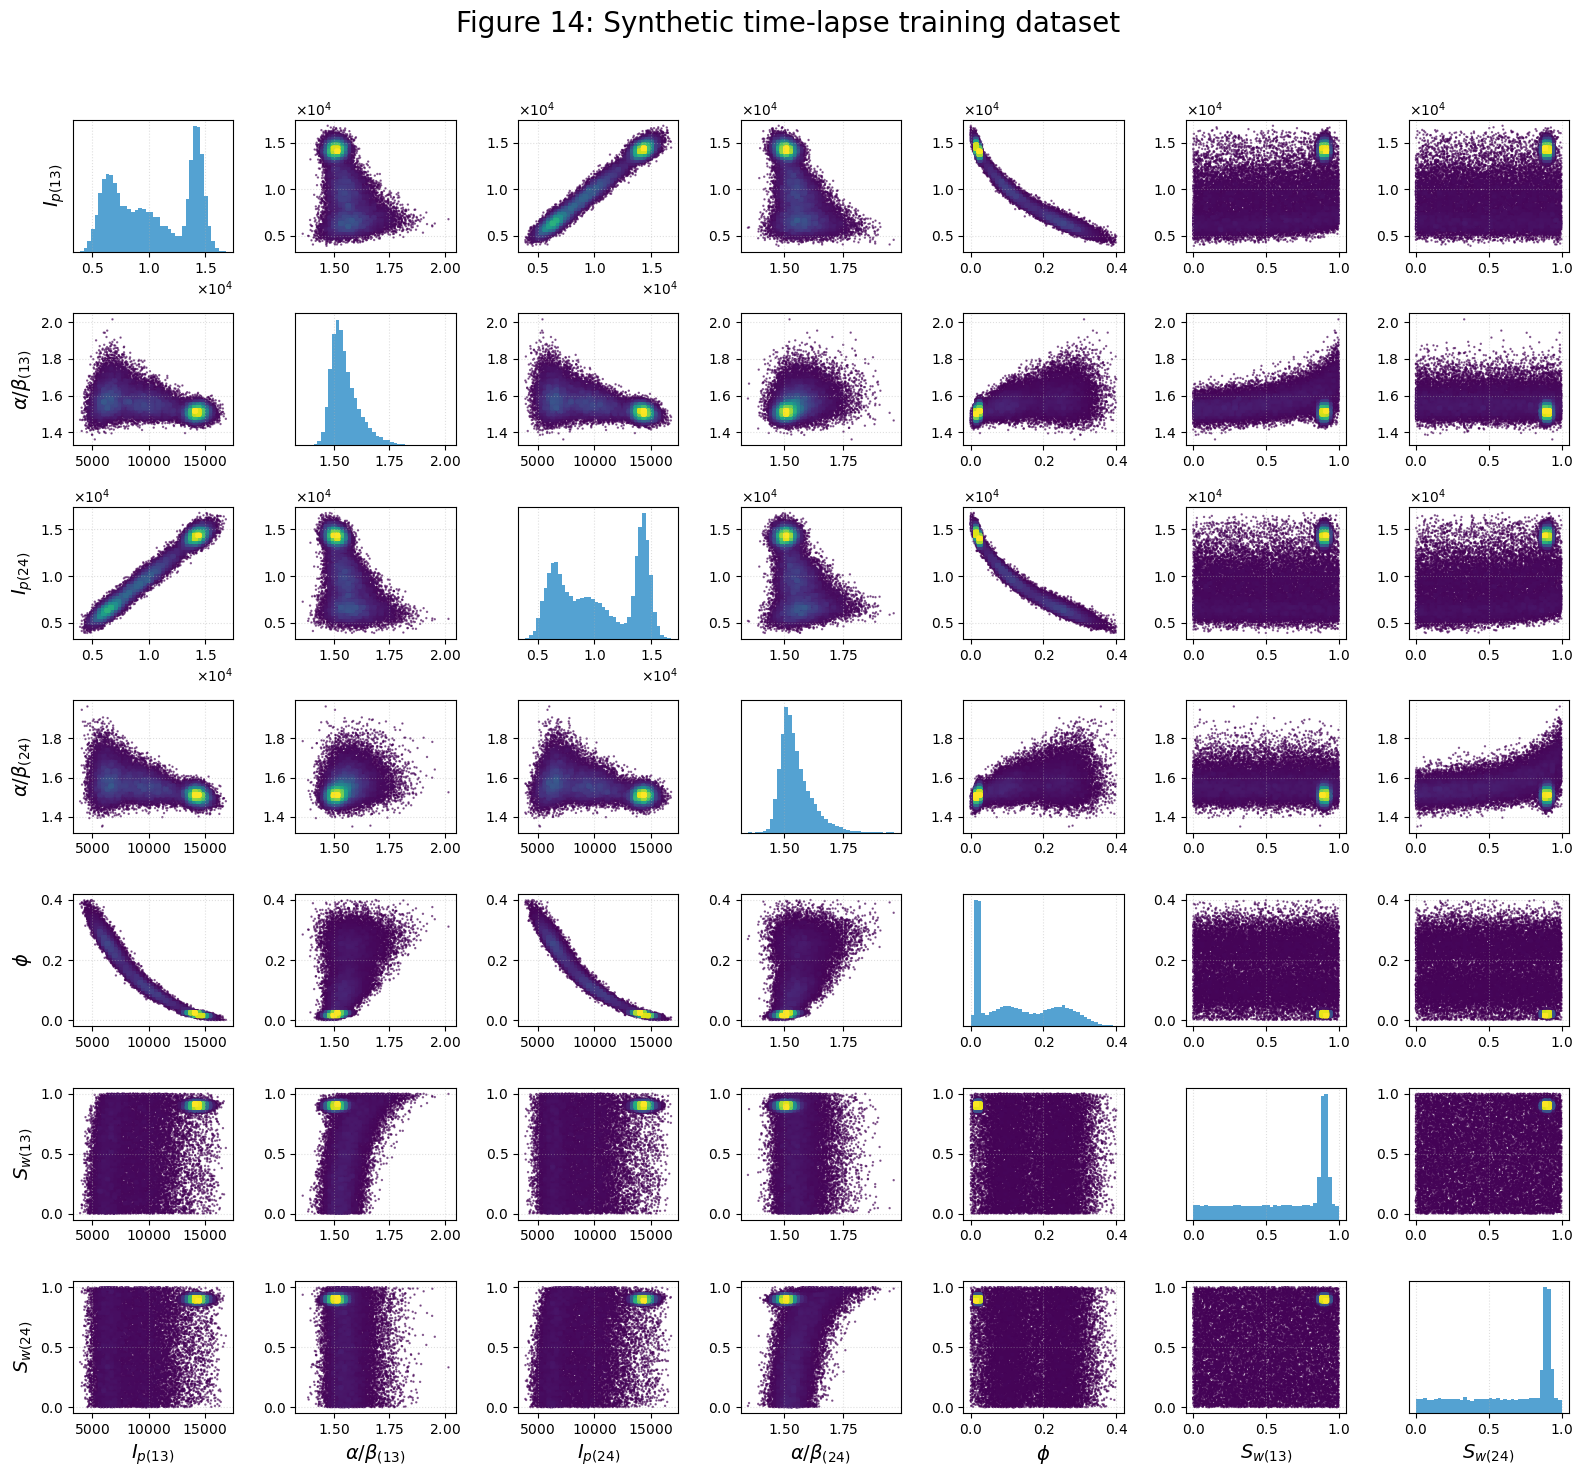

In [2]:
def rock_physics_model(phi, sw):
    """Calculates Vp, Vs, and Density based on Table 5 parameters."""
    phi = np.clip(np.abs(phi), 1e-4, 0.40)
    sw = np.clip(np.abs(sw), 0.0, 1.0)
    
    Km, Gm, rho_m = 37.0, 44.0, 2.65
    Kw, rho_w, Ko, rho_o = 3.14, 1.06, 0.53, 0.52
    phi_c, C, P = 0.4, 9, 0.060
    
    K_fl = 1.0 / (sw / Kw + (1 - sw) / Ko)
    rho_fl = sw * rho_w + (1 - sw) * rho_o
    rho_sat = (1 - phi) * rho_m + phi * rho_fl
    
    nu_m = (3 * Km - 2 * Gm) / (2 * (3 * Km + Gm))
    K_HM = ((C**2 * (1 - phi_c)**2 * Gm**2 * P) / (18 * np.pi**2 * (1 - nu_m)**2))**(1/3)
    G_HM = ((5 - 4 * nu_m) / (5 * (2 - nu_m))) * ((3 * C**2 * (1 - phi_c)**2 * Gm**2 * P) / (2 * np.pi**2 * (1 - nu_m)**2))**(1/3)
    
    Z_K, Z_G = (4/3) * G_HM, (G_HM / 6) * ((9 * K_HM + 8 * G_HM) / (K_HM + 2 * G_HM))
    K_dry = 1.0 / ((phi / phi_c) / (K_HM + Z_K) + (1 - phi / phi_c) / (Km + Z_K)) - Z_K
    G_dry = 1.0 / ((phi / phi_c) / (G_HM + Z_G) + (1 - phi / phi_c) / (Gm + Z_G)) - Z_G
    
    alpha = 1 - K_dry / Km
    K_sat = K_dry + (alpha**2) / (phi / K_fl + (1 - phi) / Km - K_dry / Km**2)
    return np.sqrt((K_sat + (4/3) * G_dry) / rho_sat) * 1000, np.sqrt(G_dry / rho_sat) * 1000, rho_sat

# 1. Generate 30,000 synthetic petrophysical samples
np.random.seed(42)
nSim = 20000 
Phi_train = np.concatenate([0.10 + 0.05 * np.random.randn(nSim//2), 0.25 + 0.05 * np.random.randn(nSim//2), 0.02 + 0.005 * np.random.randn(nSim//2)])
Sw13_train = np.concatenate([np.random.rand(nSim), 0.90 + 0.02 * np.random.randn(nSim//2)])
Sw24_train = np.concatenate([np.random.rand(nSim), 0.90 + 0.02 * np.random.randn(nSim//2)])

# Apply reflection boundaries (MATLAB logic)
Phi_train = np.where(Phi_train <= 0, -Phi_train, Phi_train)
Phi_train = np.where(Phi_train >= 0.40, 0.8 - Phi_train, Phi_train)
Sw13_train = np.where(Sw13_train <= 0, -Sw13_train, Sw13_train)
Sw13_train = np.where(Sw13_train >= 1.0, 2.0 - Sw13_train, Sw13_train)
Sw24_train = np.where(Sw24_train <= 0, -Sw24_train, Sw24_train)
Sw24_train = np.where(Sw24_train >= 1.0, 2.0 - Sw24_train, Sw24_train)

# 2. Simulate elastic properties with noise
Vp13, Vs13, Rho13 = rock_physics_model(Phi_train, Sw13_train)
Vp13 += 75.0 * np.random.randn(len(Vp13)); Vs13 += 37.5 * np.random.randn(len(Vs13)); Rho13 += 0.075 * np.random.randn(len(Rho13))
Vp24, Vs24, Rho24 = rock_physics_model(Phi_train, Sw24_train)
Vp24 += 75.0 * np.random.randn(len(Vp24)); Vs24 += 37.5 * np.random.randn(len(Vs24)); Rho24 += 0.075 * np.random.randn(len(Rho24))

train_data_3d = np.column_stack((Vp13*Rho13, Vp13/Vs13, Vp24*Rho24, Vp24/Vs24, Phi_train, Sw13_train, Sw24_train))

# 3. Plot Figure 14 (Scatter Matrix)
labels_3d = [r'$I_{p (13)}$', r'$\alpha/\beta_{(13)}$', r'$I_{p (24)}$', r'$\alpha/\beta_{(24)}$', r'$\phi$', r'$S_{w (13)}$', r'$S_{w (24)}$']

fig, axs = plt.subplots(7, 7, figsize=(16, 16), facecolor='white')
fig.suptitle('Figure 14: Synthetic time-lapse training dataset', fontsize=20, y=0.92)

for i in range(7):
    for j in range(7):
        ax = axs[i, j]
        x, y = train_data_3d[:, j], train_data_3d[:, i]
        if i == j:
            ax.hist(x, bins=40, color='#54a2d2', density=True)
            ax.set_yticks([]) 
        else:
            H, xedges, yedges = np.histogram2d(x, y, bins=40)
            densities = H[np.clip(np.digitize(x, xedges)-1, 0, 39), np.clip(np.digitize(y, yedges)-1, 0, 39)]
            sort_idx = np.argsort(densities)
            ax.scatter(x[sort_idx], y[sort_idx], c=densities[sort_idx], s=0.5, cmap='viridis', alpha=0.6)
        
        if j == 0: ax.set_ylabel(labels_3d[i], fontsize=14)
        if i == 6: ax.set_xlabel(labels_3d[j], fontsize=14)
        ax.grid(True, linestyle=':', alpha=0.4)
        
        formatter = ScalarFormatter(useMathText=True)
        formatter.set_powerlimits((-2, 3))
        ax.xaxis.set_major_formatter(formatter)
        if i != j: ax.yaxis.set_major_formatter(formatter)

plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

## Block 3: Global Scaling, Hyperparameter Tuning & Model Training

In [3]:
# 1. Global scaler fitted on both synthetic and real data
all_data_for_scaler = np.vstack((train_data_3d, reservoir_data))
scaler_3d = MinMaxScaler(feature_range=(0, 1))
scaler_3d.fit(all_data_for_scaler)

# Shuffle training data for IGMN online learning
np.random.seed(42)
train_data_3d_shuf = train_data_3d[np.random.permutation(len(train_data_3d))]
train_scaled_3d = scaler_3d.transform(train_data_3d_shuf)

in_idx_3d, out_idx_3d = [0, 1, 2, 3], [4, 5, 6]

# Validation subset for fast Optuna evaluation (10% of reservoir)
np.random.seed(99)
val_mask_opt = np.random.choice(len(reservoir_data), size=3000, replace=False)
X_val_scaled = scaler_3d.transform(reservoir_data[val_mask_opt])[:, :4]
Y_val_true = reservoir_data[val_mask_opt, 4:7]

print("=== RUNNING OPTUNA HYPERPARAMETER SEARCH (40 Trials) ===")
def objective(trial):
    tau = trial.suggest_float('tau', 0.01, 0.3, log=True)
    delta = trial.suggest_float('delta', 0.05, 0.5)
    sp_min = trial.suggest_int('sp_min', 3, 10)
    v_min = trial.suggest_int('v_min', 10, 25)
    
    igmn = IGMN(tau, delta, sp_min, v_min)
    igmn.fit(train_scaled_3d)
    
    if igmn.K < 3 or igmn.K > 20:
        return 999.0
        
    preds_sc = np.array([igmn.predict_conditional(x, in_idx_3d, out_idx_3d)[0] for x in X_val_scaled])
    dummy = np.zeros((len(preds_sc), 7))
    dummy[:, 4:7] = preds_sc
    Y_val_pred = scaler_3d.inverse_transform(dummy)[:, 4:7]
    
    rmse_val = np.sum(np.sqrt(np.mean((Y_val_true - Y_val_pred)**2, axis=0)))
    
    # Apply penalty for excessive components (aiming for ~8)
    penalty = (igmn.K - 10) * 0.02 if igmn.K > 10 else 0.0
    return rmse_val + penalty

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=40, show_progress_bar=True)

# 2. Train final model with best parameters
best_p = study.best_params
print(f"Best parameters found: tau={best_p['tau']:.3f}, delta={best_p['delta']:.3f}, sp_min={best_p['sp_min']}, v_min={best_p['v_min']}")

igmn_3d = IGMN(best_p['tau'], best_p['delta'], best_p['sp_min'], best_p['v_min'])
t0 = time.time()
igmn_3d.fit(train_scaled_3d)
train_time_3d = time.time() - t0

print(f"Final Model Trained | Neurons: {igmn_3d.K} | Time: {train_time_3d:.4f} s")

=== RUNNING OPTUNA HYPERPARAMETER SEARCH (40 Trials) ===


  0%|          | 0/40 [00:00<?, ?it/s]

Best trial: 36. Best value: 0.458159: 100%|██████████| 40/40 [04:06<00:00,  6.15s/it]


Best parameters found: tau=0.013, delta=0.183, sp_min=3, v_min=10
Final Model Trained | Neurons: 6 | Time: 4.7766 s


## Block 4: Inference, Ordinary Kriging & Figure 15

Running IGMN inversion on 37208 reservoir cells...
Applying Ordinary Kriging conditioning...


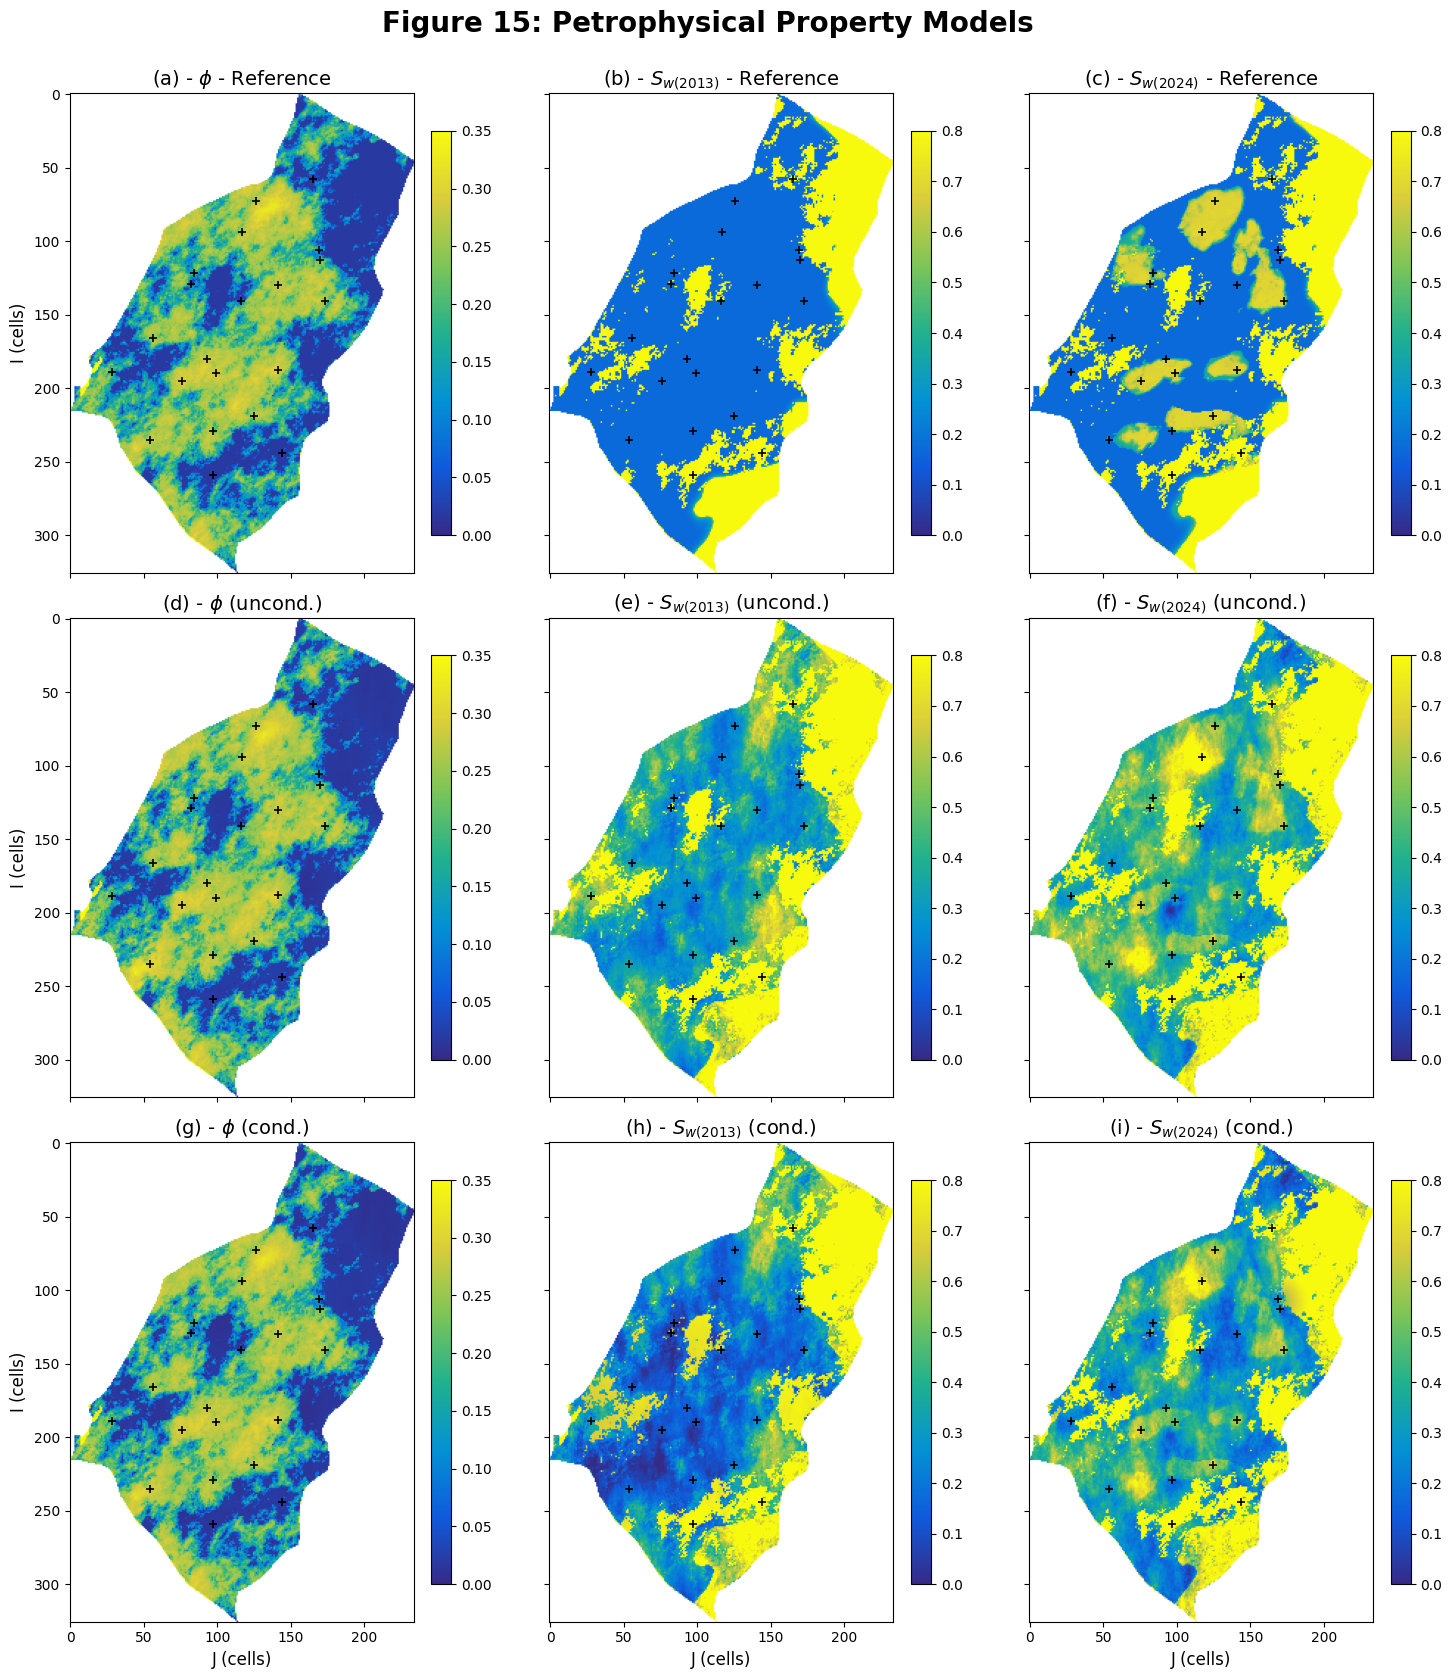

In [5]:
# 1. Unconditioned Inference
print(f"Running IGMN inversion on {len(reservoir_data)} reservoir cells...")
X_grid_scaled = scaler_3d.transform(reservoir_data)[:, :4]
preds_scaled = np.array([igmn_3d.predict_conditional(x, in_idx_3d, out_idx_3d)[0] for x in X_grid_scaled])

dummy_preds = np.zeros((len(preds_scaled), 7))
dummy_preds[:, 4:7] = preds_scaled
Y_pred_phys = scaler_3d.inverse_transform(dummy_preds)[:, 4:7]

Phi_pred, Sw13_pred, Sw24_pred = [np.full(Ip13_ref.shape, np.nan) for _ in range(3)]
Phi_pred.flat[valid_mask] = Y_pred_phys[:, 0]
Sw13_pred.flat[valid_mask] = Y_pred_phys[:, 1]
Sw24_pred.flat[valid_mask] = Y_pred_phys[:, 2]

# 2. Ordinary Kriging (Conditioning)
print("Applying Ordinary Kriging conditioning...")

# ВОССТАНОВИЛИ ПОТЕРЯННЫЕ СТРОЧКИ:
wells_x = np.array(wells_j, dtype=np.float64)
wells_y = np.array(wells_i, dtype=np.float64)

def condition_map_with_kriging(true_map, pred_map, min_val, max_val):
    true_w = true_map[wells_y.astype(int), wells_x.astype(int)]
    pred_w = pred_map[wells_y.astype(int), wells_x.astype(int)]
    
    OK = OrdinaryKriging(wells_x, wells_y, true_w - pred_w, variogram_model='spherical', verbose=False)
    residual_map, _ = OK.execute('grid', np.arange(pred_map.shape[1], dtype=np.float64), np.arange(pred_map.shape[0], dtype=np.float64))
    
    conditioned_map = pred_map + residual_map
    conditioned_map[~valid_mask.reshape(pred_map.shape)] = np.nan
    return np.clip(conditioned_map, min_val, max_val)

Phi_cond = condition_map_with_kriging(Phi_ref, Phi_pred, 0.0, 0.40)
Sw13_cond = condition_map_with_kriging(Sw13_ref, Sw13_pred, 0.0, 1.0)
Sw24_cond = condition_map_with_kriging(Sw24_ref, Sw24_pred, 0.0, 1.0)

# 3. Plot Figure 15 (3x3 Grid: Reference, Unconditioned, Conditioned)
fig, axs = plt.subplots(3, 3, figsize=(15, 18), sharex=True, sharey=True, facecolor='white')
fig.suptitle('Figure 15: Petrophysical Property Models', fontsize=20, fontweight='bold', y=0.93)

def draw_res_map(ax, grid, title, vmax):
    im = ax.imshow(grid, cmap=parula_map, vmin=0, vmax=vmax)
    ax.set_title(title, fontsize=14)
    plot_wells_only(ax)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

maps_config = [
    (0, 0, Phi_ref, r'(a) - $\phi$ - Reference', 0.35),
    (0, 1, Sw13_ref, r'(b) - $S_{w (2013)}$ - Reference', 0.8),
    (0, 2, Sw24_ref, r'(c) - $S_{w (2024)}$ - Reference', 0.8),
    (1, 0, Phi_pred, r'(d) - $\phi$ (uncond.)', 0.35),
    (1, 1, Sw13_pred, r'(e) - $S_{w (2013)}$ (uncond.)', 0.8),
    (1, 2, Sw24_pred, r'(f) - $S_{w (2024)}$ (uncond.)', 0.8),
    (2, 0, Phi_cond, r'(g) - $\phi$ (cond.)', 0.35),
    (2, 1, Sw13_cond, r'(h) - $S_{w (2013)}$ (cond.)', 0.8),
    (2, 2, Sw24_cond, r'(i) - $S_{w (2024)}$ (cond.)', 0.8)
]

for r, c, grid, title, vmax in maps_config:
    draw_res_map(axs[r, c], grid, title, vmax)
    if c == 0: axs[r, c].set_ylabel('I (cells)', fontsize=12)
    if r == 2: axs[r, c].set_xlabel('J (cells)', fontsize=12)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

## Block 5: Standard Deviation (Figure 16) & Table 8 Metrics

Calculating Uncertainty Maps (Standard Deviation)...


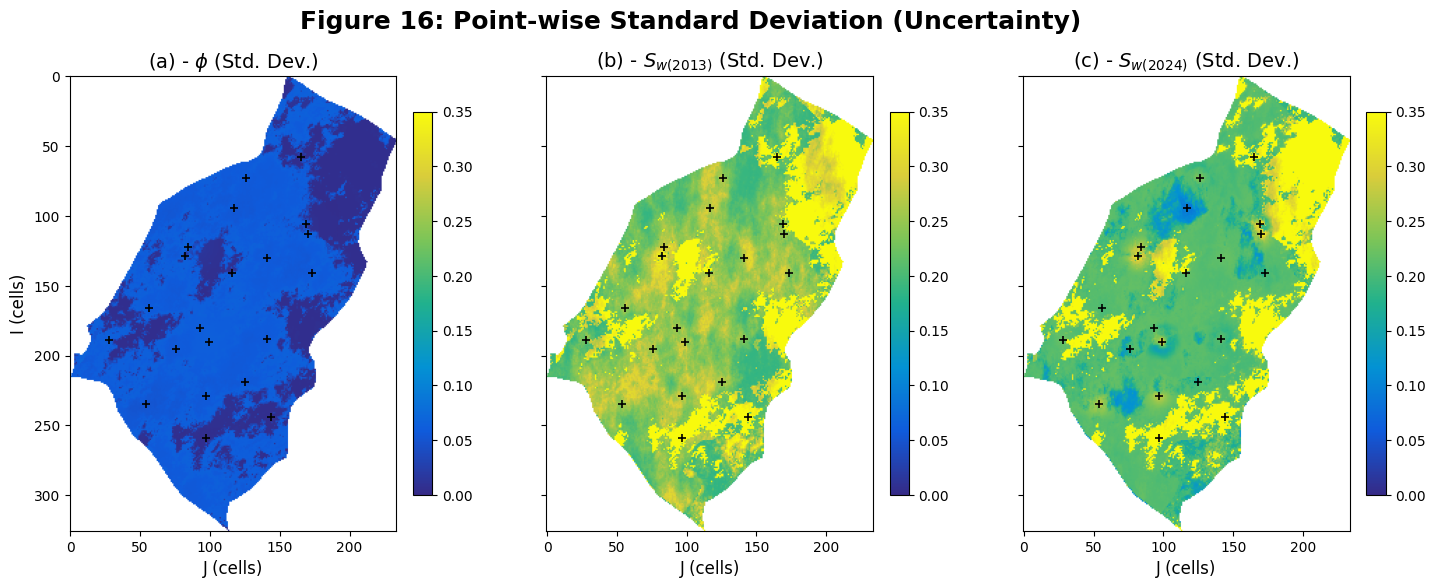


Table 8: Running time and RMSE for IGMN
| Model                     | Train Time   | # of neurons | RMSE            |
-----------------------------------------------------------------------------------------
| IGMN (Unconditioned)      | 4.6614     s | 8            | 0.474           |
| IGMN (Conditioned)        | -            | 8            | 0.410           |


In [ ]:
# 1. Calculate Standard Deviation Maps (Figure 16)
print("Calculating Uncertainty Maps (Standard Deviation)...")
grids_matlab = {'phi': np.linspace(0.0, 0.35, 100), 'sw': np.linspace(0.0, 0.80, 100)}

def calculate_std_map(model, X_t, Y_cond_flat, prop_idx_out, prop_key):
    global_idx = out_idx_3d[prop_idx_out]
    scale_factor = scaler_3d.data_max_[global_idx] - scaler_3d.data_min_[global_idx]
    mean_shift = scaler_3d.data_min_[global_idx]
    
    grid = grids_matlab[prop_key]
    std_array = np.zeros(len(X_t))
    
    for i in range(len(X_t)):
        _, weights, mus_sc, _ = model.predict_conditional(X_t[i], in_idx_3d, out_idx_3d)
        pdf_1d = np.zeros_like(grid)
        
        for j in range(model.K):
            if model.sp[j] < model.sp_min: continue
            var_sc = model.C[j][global_idx, global_idx] 
            mu_phys = mus_sc[j][prop_idx_out] * scale_factor + mean_shift
            std_phys = np.sqrt(max(var_sc, 1e-6)) * scale_factor
            pdf_1d += weights[j] * norm.pdf(grid, loc=mu_phys, scale=std_phys)
            
        if np.sum(pdf_1d) > 0: pdf_1d /= np.sum(pdf_1d)
        
        # Calculate variance around the Conditioned (Kriged) value
        variance = np.sum(pdf_1d * (grid - Y_cond_flat[i])**2)
        std_array[i] = np.sqrt(variance)
        
    std_map = np.full(Ip13_ref.shape, np.nan)
    std_map.flat[valid_mask] = std_array
    return std_map

Phi_std = calculate_std_map(igmn_3d, X_grid_scaled, Phi_cond.flatten()[valid_mask], 0, 'phi')
Sw13_std = calculate_std_map(igmn_3d, X_grid_scaled, Sw13_cond.flatten()[valid_mask], 1, 'sw')
Sw24_std = calculate_std_map(igmn_3d, X_grid_scaled, Sw24_cond.flatten()[valid_mask], 2, 'sw')

# Plot Figure 16
fig, axs = plt.subplots(1, 3, figsize=(15, 6), sharey=True, facecolor='white')
fig.suptitle('Figure 16: Point-wise Standard Deviation (Uncertainty)', fontsize=18, fontweight='bold', y=0.95)

std_configs = [
    (0, Phi_std, r'(a) - $\phi$ (Std. Dev.)'),
    (1, Sw13_std, r'(b) - $S_{w (2013)}$ (Std. Dev.)'),
    (2, Sw24_std, r'(c) - $S_{w (2024)}$ (Std. Dev.)')
]

for c, grid, title in std_configs:
    im = axs[c].imshow(grid, cmap=parula_map, vmin=0.0, vmax=0.35)
    axs[c].set_title(title, fontsize=14)
    axs[c].set_xlabel('J (cells)', fontsize=12)
    plot_wells_only(axs[c])  
    fig.colorbar(im, ax=axs[c], fraction=0.046, pad=0.04)
    if c == 0: axs[c].set_ylabel('I (cells)', fontsize=12)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# 2. Table 8: Final Metrics
def calc_rmse(true_map, pred_map):
    return np.sqrt(np.nanmean((true_map - pred_map)**2))

rmse_u = calc_rmse(Phi_ref, Phi_pred) + calc_rmse(Sw13_ref, Sw13_pred) + calc_rmse(Sw24_ref, Sw24_pred)
rmse_c = calc_rmse(Phi_ref, Phi_cond) + calc_rmse(Sw13_ref, Sw13_cond) + calc_rmse(Sw24_ref, Sw24_cond)

print("\nTable 8: Running time and RMSE for IGMN")
print("=========================================================================================")
print(f"| {'Model':<25} | {'Train Time':<12} | {'# of neurons':<12} | {'RMSE':<15} |")
print("-----------------------------------------------------------------------------------------")
print(f"| {'IGMN (Unconditioned)':<25} | {train_time_3d:<10.4f} s | {igmn_3d.K:<12} | {rmse_u:<15.3f} |")
print(f"| {'IGMN (Conditioned)':<25} | {'-':<12} | {igmn_3d.K:<12} | {rmse_c:<15.3f} |")
print("=========================================================================================")